# Сборный проект-4

Вам поручено разработать демонстрационную версию поиска изображений по запросу.

Для демонстрационной версии нужно обучить модель, которая получит векторное представление изображения, векторное представление текста, а на выходе выдаст число от 0 до 1 — покажет, насколько текст и картинка подходят друг другу.

### Описание данных

Данные доступны по [ссылке](https://code.s3.yandex.net/datasets/dsplus_integrated_project_4.zip).

В файле `train_dataset.csv` находится информация, необходимая для обучения: имя файла изображения, идентификатор описания и текст описания. Для одной картинки может быть доступно до 5 описаний. Идентификатор описания имеет формат `<имя файла изображения>#<порядковый номер описания>`.

В папке `train_images` содержатся изображения для тренировки модели.

В файле `CrowdAnnotations.tsv` — данные по соответствию изображения и описания, полученные с помощью краудсорсинга. Номера колонок и соответствующий тип данных:

1. Имя файла изображения.
2. Идентификатор описания.
3. Доля людей, подтвердивших, что описание соответствует изображению.
4. Количество человек, подтвердивших, что описание соответствует изображению.
5. Количество человек, подтвердивших, что описание не соответствует изображению.

В файле `ExpertAnnotations.tsv` содержатся данные по соответствию изображения и описания, полученные в результате опроса экспертов. Номера колонок и соответствующий тип данных:

1. Имя файла изображения.
2. Идентификатор описания.

3, 4, 5 — оценки трёх экспертов.

Эксперты ставят оценки по шкале от 1 до 4, где 1 — изображение и запрос совершенно не соответствуют друг другу, 2 — запрос содержит элементы описания изображения, но в целом запрос тексту не соответствует, 3 — запрос и текст соответствуют с точностью до некоторых деталей, 4 — запрос и текст соответствуют полностью.

В файле `test_queries.csv` находится информация, необходимая для тестирования: идентификатор запроса, текст запроса и релевантное изображение. Для одной картинки может быть доступно до 5 описаний. Идентификатор описания имеет формат `<имя файла изображения>#<порядковый номер описания>`.

В папке `test_images` содержатся изображения для тестирования модели.

Шаги проекта по задаче Сборный проект-4:

[1 Загрузка данных](#Шаг_1)

[2 Исследовательский анализ данных](#Шаг_2)
    
[3 Предобработка данных](#Шаг_3)

[4 Проверка данных](#Шаг_4)   

[5 Векторизация изображений](#Шаг_5)

[6 Векторизация текстов](#Шаг_6)

[7 Объединение векторов](#Шаг_7)

[8 Обучение модели предсказания соответствия](#Шаг_8)

[9 Тестирование модели](#Шаг_9)


#### Шаг_1
## Загрузка данных.

In [1]:
%%capture
!pip install -q transformers
!pip install -q tf-keras
!pip install -q keras_nlp
!pip install -q torch
!pip install -q torchvision

In [2]:
!pip install -q numpy==1.26.4

In [3]:
#pip uninstall tensorflow
#pip install tensorflow==2.12.0 --upgrade

In [4]:
# для работы с данными
import pandas as pd
import math
import numpy as np
import seaborn as sns
from collections import Counter

# предобработка и поиск запретов
import nltk
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
from nltk.corpus import wordnet

import tensorflow as tf
from tensorflow.keras.layers import Dense, Conv2D, Flatten,AvgPool2D,BatchNormalization,Activation,MaxPooling2D,Dropout,GlobalAveragePooling2D
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator 
from tensorflow.keras.applications.resnet import ResNet50


# векторизация и загрузка изображений
from PIL import Image
from torchvision import transforms
from torchvision.models import resnet18, ResNet18_Weights
from torchvision.models.feature_extraction import create_feature_extractor
from torchvision.io import read_image
from tqdm.notebook import tqdm

# векторизация текста
import transformers
from transformers import BertTokenizer, TFBertModel,AutoTokenizer, AutoModel

import urllib.request
from torch.utils.data import Dataset
from torch.utils.data import DataLoader

# визуализация
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# моделирование
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import GroupShuffleSplit, ParameterGrid,GridSearchCV
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import ElasticNet
from sklearn.metrics import mean_absolute_error,mean_squared_error
from sklearn.compose import make_column_transformer, make_column_selector
from sklearn.pipeline import make_pipeline
from sklearn.pipeline import Pipeline


# метрики
from sklearn.metrics import mean_squared_error

# нейросетевое моделирование
import torch
from torch import nn
from torch.nn import Sequential
from torch.optim import Adam

import pickle
import keras_nlp
from pathlib import Path

import os

nltk.download('wordnet')
nltk.download('punkt')

C:\Program Files\Anaconda\envs\practicum\lib\site-packages\scipy\__init__.py:146: UserWarning: A NumPy version >=1.17.3 and <1.25.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\ВТБ\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\ВТБ\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [5]:
#Настройки пандас
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option('display.max_columns', None)# Отображение всех столбцов в таблице;
pd.set_option('display.max_rows', None) # Отображение всех строк в таблице;
pd.set_option('display.max_colwidth', None) # текст в ячейке отражался полностью вне зависимости от длины;
pd.set_option('display.float_format', '{:.2f}'.format) #-все числа отражались с двумя знаками после запятой;

TEST_SIZE = 0.25
#максимальное количество примеров
MAX_SAMPLE = 10
RANDOM_STATE = 42 
# папка для хранения временных данных
TMP='./cache'

In [6]:
#Путь к данным.
data_path = (r'C:\Users\Desktop\practicum\Сборный 4\to_upload')
train_data_path = (r'C:\Users\Desktop\practicum\Сборный 4\to_upload\\train_images')
test_data_path = (r'C:\Users\Desktop\practicum\Сборный 4\to_upload\\test_images')

In [7]:
#Читаем файл с ответами краудсорсинга
crowd_annotations = pd.read_csv(os.path.join(data_path, 'CrowdAnnotations.tsv'), sep='\t', header=None,
                               names=['image', 'query_id', 'positive_share', 'positive_amount', 'negative_amount'])
#Читаем файл с ответами экспертов
expert_annotations = pd.read_csv(os.path.join(data_path, 'ExpertAnnotations.tsv'), sep='\t', header=None,
                               names=['image', 'query_id', 'expert_1', 'expert_2', 'expert_3'])


In [8]:
#Загружаем тренировочный датасет
train_df = pd.read_csv(os.path.join(data_path, 'train_dataset.csv'))

**Вывод:** тренировочные данные загружены.

#### Шаг_2
## Исследовательский анализ данных

Наш датасет содержит экспертные и краудсорсинговые оценки соответствия текста и изображения.

В файле с экспертными мнениями для каждой пары изображение-текст имеются оценки от трёх специалистов. Для решения задачи вы должны эти оценки агрегировать — превратить в одну. Существует несколько способов агрегации оценок, самый простой — голосование большинства: за какую оценку проголосовала большая часть экспертов (в нашем случае 2 или 3), та оценка и ставится как итоговая. Поскольку число экспертов меньше числа классов, может случиться, что каждый эксперт поставит разные оценки, например: 1, 4, 2. В таком случае данную пару изображение-текст можно исключить из датасета.

Вы можете воспользоваться другим методом агрегации оценок или придумать свой.

В файле с краудсорсинговыми оценками информация расположена в таком порядке:

1. Доля исполнителей, подтвердивших, что текст **соответствует** картинке.
2. Количество исполнителей, подтвердивших, что текст **соответствует** картинке.
3. Количество исполнителей, подтвердивших, что текст **не соответствует** картинке.

После анализа экспертных и краудсорсинговых оценок выберите либо одну из них, либо объедините их в одну по какому-то критерию: например, оценка эксперта принимается с коэффициентом 0.6, а крауда — с коэффициентом 0.4.

Ваша модель должна возвращать на выходе вероятность соответствия изображения тексту, поэтому целевая переменная должна иметь значения от 0 до 1.


In [9]:
def data_info(df):
#Общая инвормация
#    print('Информация по',return(df))
    print('Количество строк - ', df.shape[0])
    print('Количество столбцов -', df.shape[1],end='\n\n')
    df.info()
    print()
    display(df.head(3))
    print()
    print('Описание данных')
    display(df.describe())
#поиск пропусков    
    isnaPD = pd.concat([(df.isna().sum()),((df.isna().sum()/df.isna().count()*100).round(2))], axis =1)
    isnaPD.columns= ['Количество пропусков','% пропусков']
    display(isnaPD)
#Поиск явных дубликатов
    print()
    print('Количество явных дубликатов в данных:',df.duplicated().sum(),end='\n')
    print('Доля явных дубликатов:', round(df.duplicated().sum()/df.shape[0]*100, 2),'%',end='\n\n')
#Проверка на неявные дубликаты
#    cat_col_names = df.select_dtypes(exclude='number').columns.tolist()
#    for i in cat_col_names:
#        print (df[i].unique())
#        print()

In [10]:
#Подсчет выбросов и пропусков в количественных значениях
def outliners(df):
    for i in num_col_names:
        outliers = df[i].apply(lambda x: abs(x - df[i].mean()) > 3 * df[i].std())
        print(i, '\n')
        print(df[i].describe())
        print()
        print('Процент выбросов в',i,'=',(outliers.sum()/len(df[i])*100).round(2))
        print('Количество пропусков в',i,'=',df[i].isna().sum())
        print('% пропусков в',i,'=',(df[i].isna().sum()/df[i].isna().count()*100).round(2))
        print()

In [11]:
##Функция анализа числовых значений
def hist_box(data, column):#, target):
    plt.figure(figsize=(15, 5))
    plt.subplot(1, 2, 1)
    sns.histplot(data[column])#, hue = target)
    plt.xlabel(f'Значения столбца "{column}"')
    plt.ylabel('Частота')
    plt.title(f'Гистограмма для "{column}"')
    plt.axvline(np.median(data[column]), color='red', linestyle='dashed', linewidth=3, label='Медиана')
    plt.axvline(np.mean(data[column]), color='black', linestyle='dashed', linewidth=3, label='Среднее')
    plt.axvline(np.percentile(data[column], 25), color='orange', linestyle='dashed', linewidth=3, label='1-й квартиль')
    plt.axvline(np.percentile(data[column], 75), color='green', linestyle='dashed', linewidth=3, label='3-й квартиль')
    
    plt.subplot(1, 2, 2)
    plt.xlabel(f'Значения столбца {column}')
    plt.title(f'Диаграмма размаха для {column}')
    sns.boxplot(x=data[column])

In [12]:
#crowd_annotations
#expert_annotations
#train_df

In [13]:
data_info(crowd_annotations)

Количество строк -  47830
Количество столбцов - 5

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47830 entries, 0 to 47829
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   image            47830 non-null  object 
 1   query_id         47830 non-null  object 
 2   positive_share   47830 non-null  float64
 3   positive_amount  47830 non-null  int64  
 4   negative_amount  47830 non-null  int64  
dtypes: float64(1), int64(2), object(2)
memory usage: 1.8+ MB



,image,query_id,positive_share,positive_amount,negative_amount
0,1056338697_4f7d7ce270.jpg,1056338697_4f7d7ce270.jpg#2,1.00,3,0
1,1056338697_4f7d7ce270.jpg,114051287_dd85625a04.jpg#2,0.00,0,3
2,1056338697_4f7d7ce270.jpg,1427391496_ea512cbe7f.jpg#2,0.00,0,3



Описание данных


,positive_share,positive_amount,negative_amount
count,47830.00,47830.00,47830.00
mean,0.07,0.21,2.82
std,0.21,0.63,0.66
min,0.00,0.00,0.00
25%,0.00,0.00,3.00
50%,0.00,0.00,3.00
75%,0.00,0.00,3.00
max,1.00,5.00,6.00


,Количество пропусков,% пропусков
image,0,0.00
query_id,0,0.00
positive_share,0,0.00
positive_amount,0,0.00
negative_amount,0,0.00



Количество явных дубликатов в данных: 0
Доля явных дубликатов: 0.0 %



In [14]:
num_col_names = crowd_annotations.select_dtypes(include='number').columns.tolist()
outliners(crowd_annotations)

positive_share 

count   47830.00
mean        0.07
std         0.21
min         0.00
25%         0.00
50%         0.00
75%         0.00
max         1.00
Name: positive_share, dtype: float64

Процент выбросов в positive_share = 2.79
Количество пропусков в positive_share = 0
% пропусков в positive_share = 0.0

positive_amount 

count   47830.00
mean        0.21
std         0.63
min         0.00
25%         0.00
50%         0.00
75%         0.00
max         5.00
Name: positive_amount, dtype: float64

Процент выбросов в positive_amount = 2.82
Количество пропусков в positive_amount = 0
% пропусков в positive_amount = 0.0

negative_amount 

count   47830.00
mean        2.82
std         0.66
min         0.00
25%         3.00
50%         3.00
75%         3.00
max         6.00
Name: negative_amount, dtype: float64

Процент выбросов в negative_amount = 3.22
Количество пропусков в negative_amount = 0
% пропусков в negative_amount = 0.0



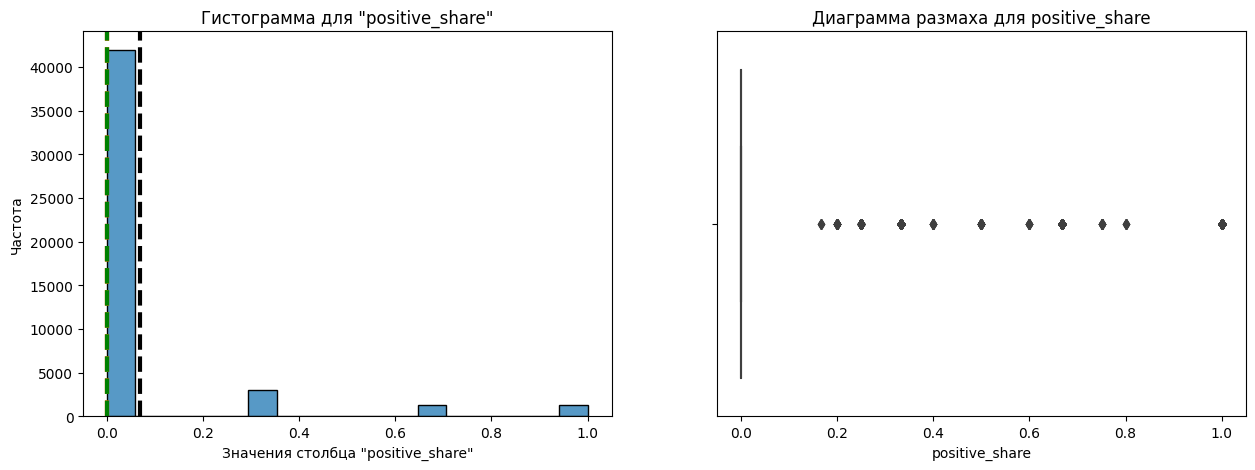

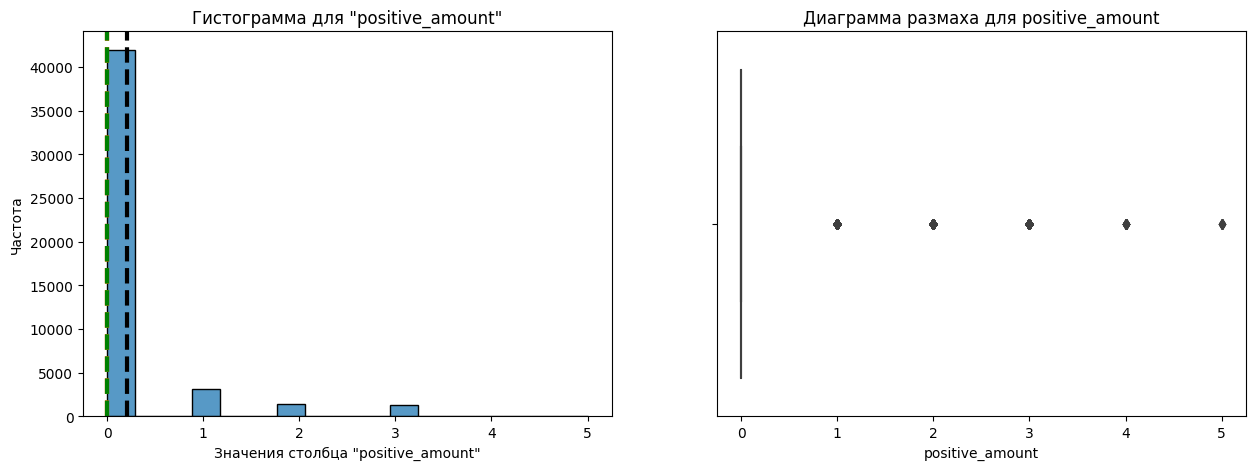

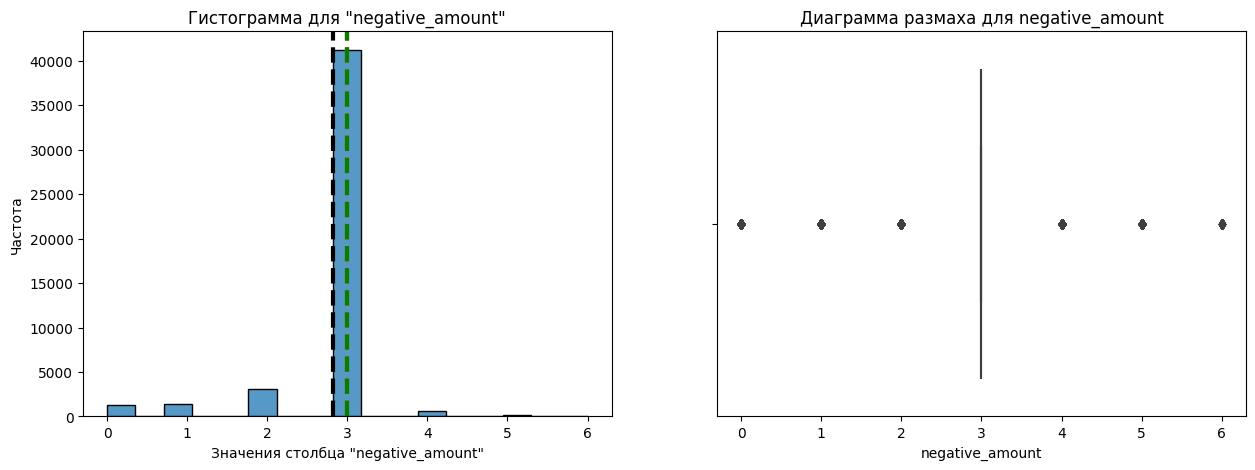

In [15]:
for i in num_col_names:
    hist_box(crowd_annotations, i)

В crowd_annotations 47830 оценок.
Cреднее количество проголосовавших за соответствие ниже чем тех кто голосует за несоответствие.
Медиана количество оценок для подтвердивших соответствие = 0
Медиана количество оценок для подтвердивших несоответствие = 3
на краудсорсинге чаще дают отрицательный ответ

In [16]:
data_info(expert_annotations)

Количество строк -  5822
Количество столбцов - 5

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5822 entries, 0 to 5821
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   image     5822 non-null   object
 1   query_id  5822 non-null   object
 2   expert_1  5822 non-null   int64 
 3   expert_2  5822 non-null   int64 
 4   expert_3  5822 non-null   int64 
dtypes: int64(3), object(2)
memory usage: 227.5+ KB



,image,query_id,expert_1,expert_2,expert_3
0,1056338697_4f7d7ce270.jpg,2549968784_39bfbe44f9.jpg#2,1,1,1
1,1056338697_4f7d7ce270.jpg,2718495608_d8533e3ac5.jpg#2,1,1,2
2,1056338697_4f7d7ce270.jpg,3181701312_70a379ab6e.jpg#2,1,1,2



Описание данных


,expert_1,expert_2,expert_3
count,5822.00,5822.00,5822.00
mean,1.44,1.62,1.88
std,0.79,0.86,0.90
min,1.00,1.00,1.00
25%,1.00,1.00,1.00
50%,1.00,1.00,2.00
75%,2.00,2.00,2.00
max,4.00,4.00,4.00


,Количество пропусков,% пропусков
image,0,0.00
query_id,0,0.00
expert_1,0,0.00
expert_2,0,0.00
expert_3,0,0.00



Количество явных дубликатов в данных: 0
Доля явных дубликатов: 0.0 %



In [17]:
num_col_names = expert_annotations.select_dtypes(include='number').columns.tolist()
outliners(expert_annotations)

expert_1 

count   5822.00
mean       1.44
std        0.79
min        1.00
25%        1.00
50%        1.00
75%        2.00
max        4.00
Name: expert_1, dtype: float64

Процент выбросов в expert_1 = 4.24
Количество пропусков в expert_1 = 0
% пропусков в expert_1 = 0.0

expert_2 

count   5822.00
mean       1.62
std        0.86
min        1.00
25%        1.00
50%        1.00
75%        2.00
max        4.00
Name: expert_2, dtype: float64

Процент выбросов в expert_2 = 0.0
Количество пропусков в expert_2 = 0
% пропусков в expert_2 = 0.0

expert_3 

count   5822.00
mean       1.88
std        0.90
min        1.00
25%        1.00
50%        2.00
75%        2.00
max        4.00
Name: expert_3, dtype: float64

Процент выбросов в expert_3 = 0.0
Количество пропусков в expert_3 = 0
% пропусков в expert_3 = 0.0



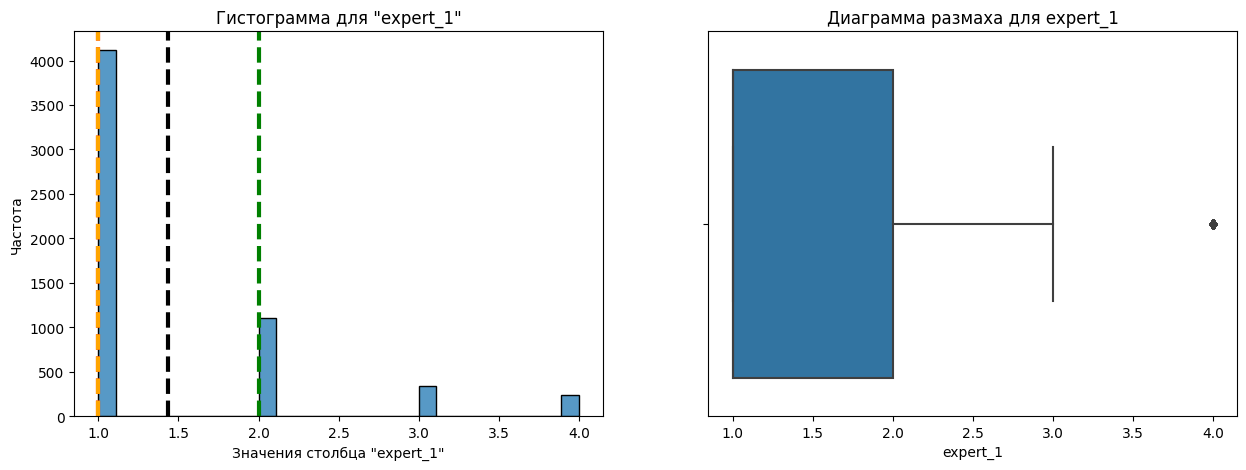

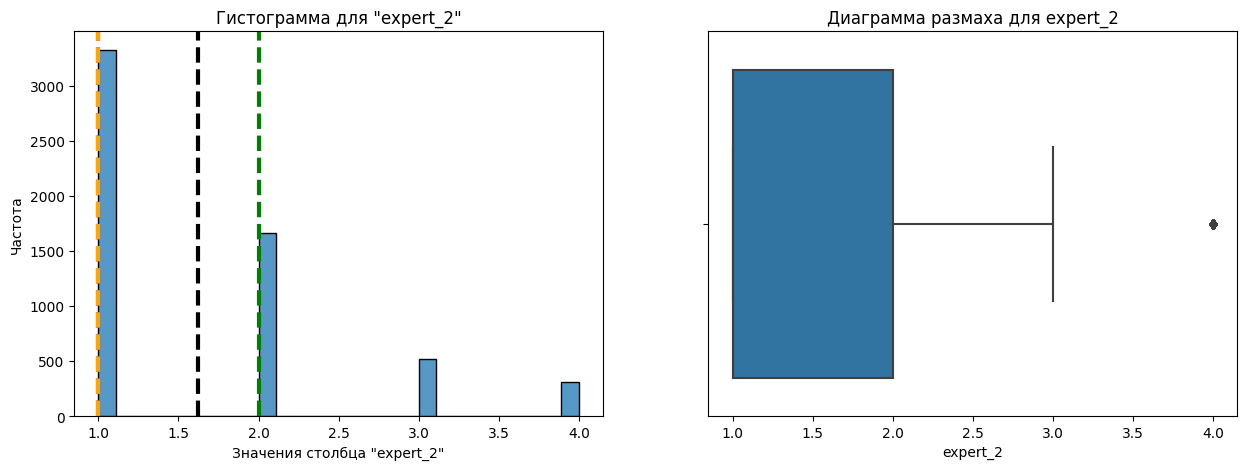

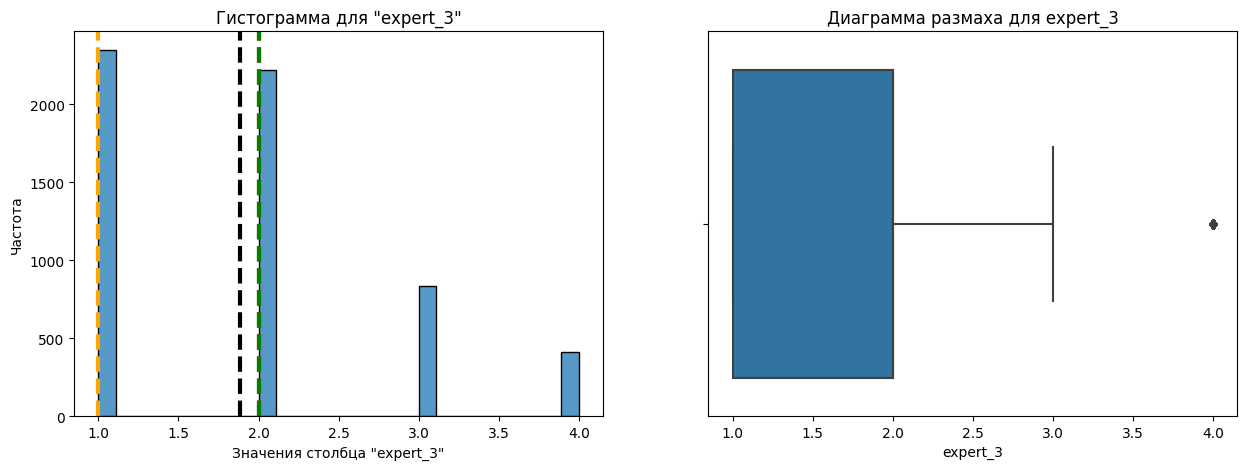

In [18]:
for i in num_col_names:
    hist_box(expert_annotations, i)

В экспертном датасете 5822 оценок
судя по медиане и среднему, 3-й эксперт завышает ответы

In [19]:
data_info(train_df)

Количество строк -  5822
Количество столбцов - 3

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5822 entries, 0 to 5821
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   image       5822 non-null   object
 1   query_id    5822 non-null   object
 2   query_text  5822 non-null   object
dtypes: object(3)
memory usage: 136.6+ KB



,image,query_id,query_text
0,1056338697_4f7d7ce270.jpg,2549968784_39bfbe44f9.jpg#2,A young child is wearing blue goggles and sitting in a float in a pool .
1,1262583859_653f1469a9.jpg,2549968784_39bfbe44f9.jpg#2,A young child is wearing blue goggles and sitting in a float in a pool .
2,2447284966_d6bbdb4b6e.jpg,2549968784_39bfbe44f9.jpg#2,A young child is wearing blue goggles and sitting in a float in a pool .



Описание данных


,image,query_id,query_text
count,5822,5822,5822
unique,1000,977,977
top,2061354254_faa5bd294b.jpg,2600867924_cd502fc911.jpg#2,"Two dogs , one brown and white and one black and white , run on a field ."
freq,10,34,34


,Количество пропусков,% пропусков
image,0,0.00
query_id,0,0.00
query_text,0,0.00



Количество явных дубликатов в данных: 0
Доля явных дубликатов: 0.0 %



**Выввод**: Проведен анализ данных.

Пропуски и дубликаты отсутствуют.

Выбросы присутствуют в crowd_annotations до 3% и expert_annotations по эксперту 1 до 5%

В crowd_annotations 47830 оценок. Cреднее количество проголосовавших за соответствие ниже чем тех кто голосует за несоответствие. Медиана количество оценок для подтвердивших соответствие = 0 Медиана количество оценок для подтвердивших несоответствие = 3 на краудсорсинге чаще дают отрицательный ответ.

В expert_annotations 5822 оценок судя по медиане и среднему, 3-й эксперт завышает ответы

#### Шаг_3
## Предобработка данных


Оперделим значение которое встерячатся наибоеле часто, причем если все экперты различаются во мнениях поставим значение(-1).

In [20]:
# Определим наиболее частое значение
def frequent(numbers):
    if len(set(numbers)) == 3:
        return -1
    else:
        counter = Counter(numbers)
        return max(counter, key=counter.get)

In [21]:
# Применяем функцию к последним трём столбцам датафрейма
expert_annotations['most_frequent'] = (expert_annotations[['expert_1', 'expert_2', 'expert_3']]
                                       .apply(lambda row: frequent(row), axis=1))

In [22]:
expert_annotations.tail(20)

,image,query_id,expert_1,expert_2,expert_3,most_frequent
5802,968081289_cdba83ce2e.jpg,2396025708_e4a72e2558.jpg#2,2,2,2,2
5803,968081289_cdba83ce2e.jpg,3162045919_c2decbb69b.jpg#2,1,1,1,1
5804,968081289_cdba83ce2e.jpg,533979933_a95b03323b.jpg#2,1,2,2,2
5805,968081289_cdba83ce2e.jpg,997722733_0cb5439472.jpg#2,1,1,1,1
5806,979383193_0a542a059d.jpg,1554713437_61b64527dd.jpg#2,1,1,1,1
5807,979383193_0a542a059d.jpg,1962729184_6996e128e7.jpg#2,2,2,2,2
5808,979383193_0a542a059d.jpg,3079787482_0757e9d167.jpg#2,2,3,3,3
5809,979383193_0a542a059d.jpg,3108197858_441ff38565.jpg#2,1,2,3,-1
5810,979383193_0a542a059d.jpg,3244747165_17028936e0.jpg#2,2,2,2,2
5811,979383193_0a542a059d.jpg,3468694409_a51571d621.jpg#2,1,1,1,1


In [23]:
#sns.histplot(expert_annotations['most_frequent'])

In [24]:
print('Размер датафрейма до:', expert_annotations.shape)
expert_annotations = expert_annotations[expert_annotations['most_frequent'] != -1]
print('Размер датафрейма после:', expert_annotations.shape)

Размер датафрейма до: (5822, 6)
Размер датафрейма после: (5696, 6)


Эксперты не сходятся во мнении в 2% случаев. Исключены спорные моменты.


In [25]:
# рассчитаем вероятность соттветсвия описания картинке.
expert_annotations['positive_probability'] = expert_annotations['most_frequent'].apply(lambda x: (x-1)/3)

In [26]:
expert_annotations.sample(30)

,image,query_id,expert_1,expert_2,expert_3,most_frequent,positive_probability
490,1584315962_5b0b45d02d.jpg,3494394662_3edfd4a34c.jpg#2,1,3,3,3,0.67
979,2216695423_1362cb25f3.jpg,3048597471_5697538daf.jpg#2,2,2,2,2,0.33
2167,2764178773_d63b502812.jpg,566397227_a469e9e415.jpg#2,1,1,1,1,0.00
2529,2922973230_5a769ef92a.jpg,3004823335_9b82cbd8a7.jpg#2,2,2,2,2,0.33
890,219070971_ae43410b9e.jpg,541063517_35044c554a.jpg#2,2,2,3,2,0.33
2465,2901880865_3fd7b66a45.jpg,3162045919_c2decbb69b.jpg#2,4,4,4,4,1.00
4400,3518126579_e70e0cbb2b.jpg,3701291852_373ea46bb6.jpg#2,2,2,2,2,0.33
4616,3578841731_f775cab089.jpg,2301525531_edde12d673.jpg#2,1,1,1,1,0.00
3906,3364151356_eecd07a23e.jpg,3630641436_8f9ac5b9b2.jpg#2,1,2,2,2,0.33
1260,2373234213_4ebe9c4ee5.jpg,1509786421_f03158adfc.jpg#2,1,1,2,1,0.00


In [27]:
#объединим данные
train_df = train_df.merge(crowd_annotations, how='left').merge(expert_annotations, how='left')

In [28]:
train_df.head(1)

,image,query_id,query_text,positive_share,positive_amount,negative_amount,expert_1,expert_2,expert_3,most_frequent,positive_probability
0,1056338697_4f7d7ce270.jpg,2549968784_39bfbe44f9.jpg#2,A young child is wearing blue goggles and sitting in a float in a pool .,0.00,0.00,3.00,1.00,1.00,1.00,1.00,0.00


Вычислим вероятность на основе данных о доле краудсорсинговых положительных отзывов о (crowd_p) и вероятности положительных отзывов от экспертов (expert_p). Если значение crowd_p отсутствует (NaN), функция использует значение expert_p и наоборот. Если оба значения отсутствуют, возвращает NaN.

In [29]:
def construct_probability(row: pd.Series) -> float:
    crowd_p = row['positive_share']
    expert_p = row['positive_probability']
    if math.isnan(crowd_p):
        return expert_p
    elif math.isnan(expert_p):
        return crowd_p
    else:
        return expert_p * 0.7 + crowd_p * 0.3

# применим функцию и оставим только целевые данные
train_df['probability'] = train_df.apply(construct_probability, axis=1)
train_df = train_df[['image', 'query_id', 'query_text', 'probability']]

In [30]:
train_df = train_df[train_df['probability'].notna()]

In [31]:
display(train_df.tail(5))

print('Размер итогового дата-фрейма:', train_df.shape)

,image,query_id,query_text,probability
5817,757046028_ff5999f91b.jpg,2061144717_5b3a1864f0.jpg#2,A man in an ampitheater talking to a boy .,0.33
5818,799486353_f665d7b0f0.jpg,2196107384_361d73a170.jpg#2,a old man walks down the uncrowded road .,0.00
5819,909808296_23c427022d.jpg,2112921744_92bf706805.jpg#2,A dog stands on the side of a grassy cliff .,0.33
5820,929679367_ff8c7df2ee.jpg,3651971126_309e6a5e22.jpg#2,A blurry photo of two dogs .,0.47
5821,968081289_cdba83ce2e.jpg,2292406847_f366350600.jpg#2,A man rows his boat below .,0.00


Размер итогового дата-фрейма: (5767, 4)


In [32]:
# создадим функцию для просмотра изображения

def image_show(images, titles=None, nums=None):
   
    fig = plt.figure(figsize=(10, len(images) * 3))

    for i in range(len(images)):
        fig.add_subplot(len(images), 1, i + 1)
        img = Image.open(images[i])
        if titles != None:
            if nums != None:
                if nums[i] == None:
                    plt.title(f'\n{titles[i]}', fontsize = 10)
                else:
                    plt.title(f'\n{str(nums[i])}\n{titles[i]}', fontsize = 10)
            else:
                plt.title(f'\n{titles[i]}', fontsize = 10)
        plt.axis('off')
        plt.imshow(img)

    plt.show()

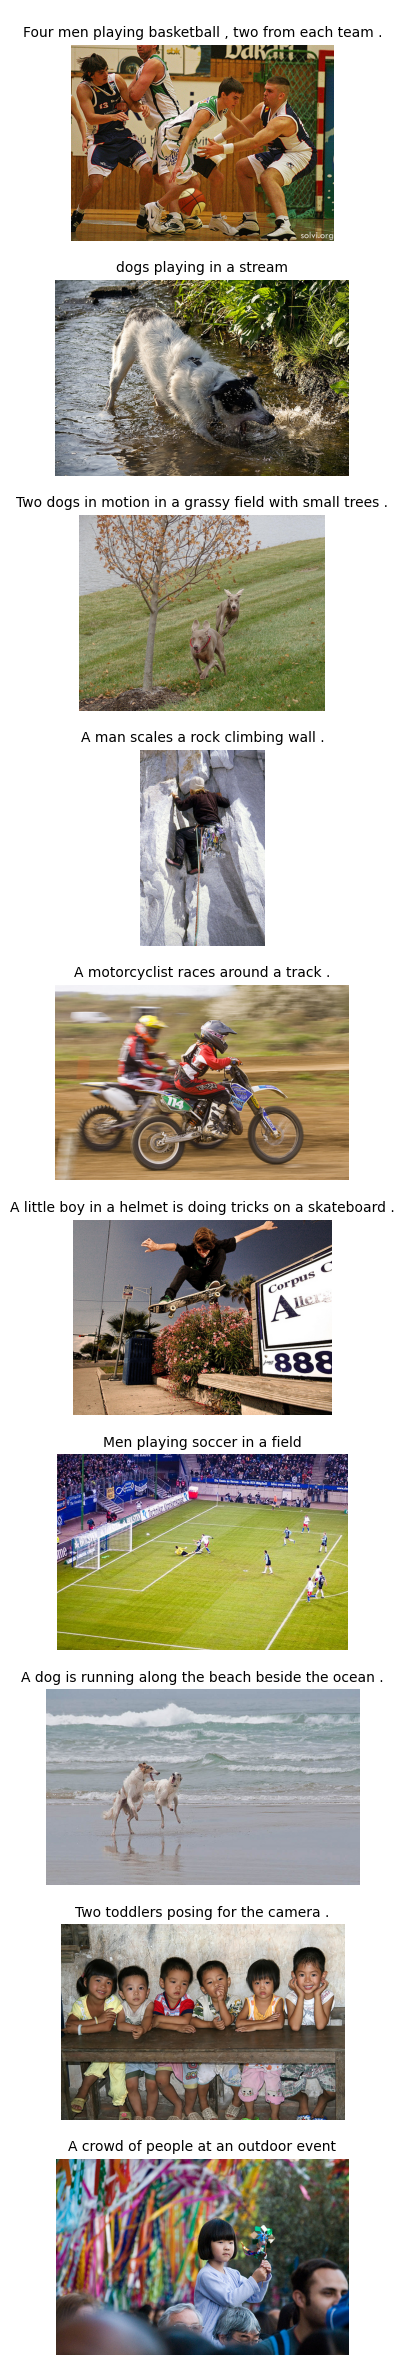

In [33]:
visual_set = train_df[train_df['probability'] > 0.5].sample(MAX_SAMPLE).copy()
visual_set.reset_index(inplace=True)

images = []
labels = []

for i in range(visual_set.shape[0]):
    images.append(f'{train_data_path}/{visual_set.iloc[i]["image"]}')
    labels.append(visual_set.iloc[i]['query_text'])

image_show(images, labels)

**Вывод:** Выполнена предобработка данных.
Исключены спорные моменты и сформирован целевой признак.

#### Шаг_4
## Проверка данных

В некоторых странах, где работает ваша компания, действуют ограничения по обработке изображений: поисковым сервисам и сервисам, предоставляющим возможность поиска, запрещено без разрешения родителей или законных представителей предоставлять любую информацию, в том числе, но не исключительно тексты, изображения, видео и аудио, содержащие описание, изображение или запись голоса детей. Ребёнком считается любой человек, не достигший 16 лет.
В вашем сервисе строго следуют законам стран, в которых работают. Поэтому при попытке посмотреть изображения, запрещённые законодательством, вместо картинок показывается дисклеймер:

⎪ This image is unavailable in your country in compliance with local laws

Однако у вас в PoC нет возможности воспользоваться данным функционалом. Поэтому все изображения, которые нарушают данный закон, нужно удалить из обучающей выборки.

In [34]:
# создаем список слов потенциально нарушающих законодательство
RESTRICT = ['child', 
             'children',
             'baby', 
             'babies',
             'boy',
             'boys',
             'girl',
             'girls',
             'kid',
             'kids',
             'infant',
             'infants',
             'toddler',
             'toddlers']


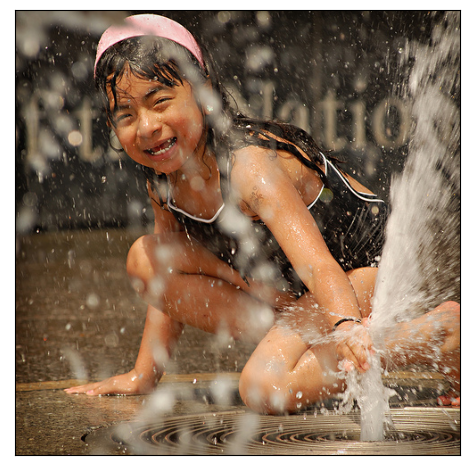

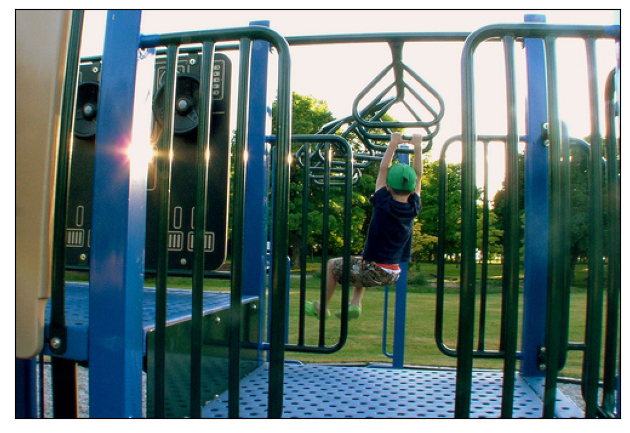

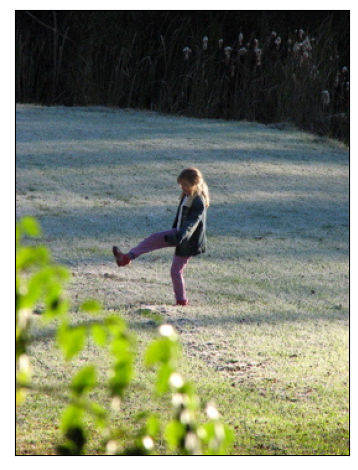

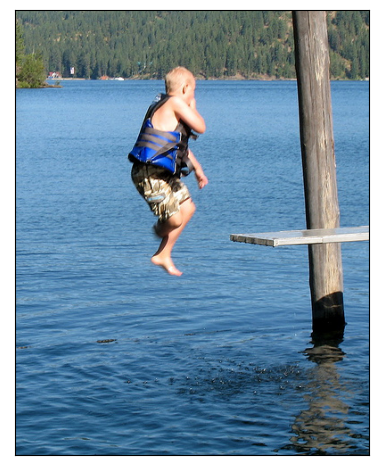

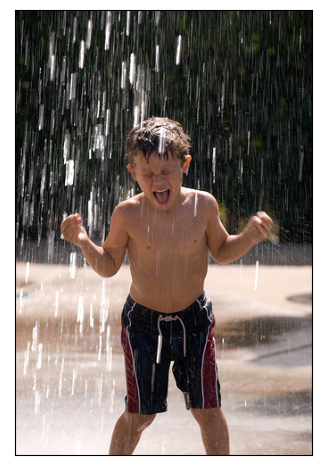

In [35]:
# посмотрим что за изображения нам попадутся по запросу включающему стоп слова
mask = (train_df['query_text']
        .apply(lambda query: any(word in query.lower() for word in RESTRICT)))

pics_to_remove = train_df[mask]['query_id'].apply(lambda x: x[:-2]).unique()

for image_path in np.random.choice(pics_to_remove, 5):
    img = mpimg.imread(os.path.join(train_data_path, image_path))
    imgplot = plt.imshow(img)
    plt.xticks([])
    plt.yticks([])
    plt.tight_layout()
    plt.show()

#### Шаг_5
## Векторизация изображений

In [36]:
# удалим такие изображения
a = train_df.shape[0]
train_df = train_df[~train_df['image'].isin(pics_to_remove)]
print(f'Удалено {a - train_df.shape[0]} изображений')
print('Размер датасета', train_df.shape[0])

Удалено 1733 изображений
Размер датасета 4034


In [37]:
train_df.shape

(4034, 4)

**Вывод:** Исключены запрещенные изображения.

In [38]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [39]:
# Step 1: Initialize the model with the best available weights
weights = ResNet18_Weights.DEFAULT
model = resnet18(weights=weights)
model.to(device)
model.eval()

# Step 2: Initialize the inference transforms
preprocess = weights.transforms(antialias=True)

# Step 3: Create the feature extractor with the required nodes
return_nodes = {'flatten': 'flatten'}
feature_extractor = create_feature_extractor(model, return_nodes=return_nodes)

In [40]:
#Получение вектора изображения
def get_image_vector(image_path):
    # Step 4: Load the image(s) and apply inference preprocessing transforms
    image = read_image(image_path).unsqueeze(0)
    model_input = preprocess(image).to(device)

    with torch.no_grad():
        # Step 5: Extract the features
        features = feature_extractor(model_input)
        flatten_fts = features["flatten"].squeeze()

        # тут специально переводим на CPU
        return flatten_fts.to('cpu').detach().numpy()

In [41]:
# выберим одно изображение для проверки
get_image_vector(train_data_path + '/53043785_c468d6f931.jpg').shape

(512,)

In [42]:
# словарь для хранения результата обработки
image_vectors = {}

In [43]:
def images2vector(folder):
    count = 0

    for p in Path(folder).glob('*.jpg'):
        count+=1

    with tqdm(total=count) as pbar:
        for p in Path(folder).glob('*.jpg'):
            image_vectors[p.name] = get_image_vector(folder + f'/{p.name}')
#            pbar.update(1)

In [44]:
# используем кэш
if os.path.exists(TMP + '/image_vectors.pickle'):
    image_vectors = pickle.load(open(TMP + '/image_vectors.pickle', 'rb'))
else:
    images2vector(train_data_path)
    pickle.dump(image_vectors, file = open(TMP + '/image_vectors.pickle', 'wb'))

In [45]:
# проверим сформированный объект
img1 = list(image_vectors.keys())[0]
image_vectors[img1].shape

(512,)

In [46]:
print(f'''Векторизация изображения на заранее обученной модели resnet18 позволило сделать вектор длинной {image_vectors[img1].shape[0]}''')

Векторизация изображения на заранее обученной модели resnet18 позволило сделать вектор длинной 512


#### Шаг_6
## Векторизация текстов

In [47]:
# обучать будем на специальной модели
tokenizer = AutoTokenizer.from_pretrained('distilbert-base-uncased')
model = AutoModel.from_pretrained('distilbert-base-uncased')

model.to(device)

DistilBertModel(
  (embeddings): Embeddings(
    (word_embeddings): Embedding(30522, 768, padding_idx=0)
    (position_embeddings): Embedding(512, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (transformer): Transformer(
    (layer): ModuleList(
      (0-5): 6 x TransformerBlock(
        (attention): DistilBertSdpaAttention(
          (dropout): Dropout(p=0.1, inplace=False)
          (q_lin): Linear(in_features=768, out_features=768, bias=True)
          (k_lin): Linear(in_features=768, out_features=768, bias=True)
          (v_lin): Linear(in_features=768, out_features=768, bias=True)
          (out_lin): Linear(in_features=768, out_features=768, bias=True)
        )
        (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
        (ffn): FFN(
          (dropout): Dropout(p=0.1, inplace=False)
          (lin1): Linear(in_features=768, out_features=3072, bias=True)
          (lin2): L

In [48]:
#Mean Pooling - Take attention mask into account for correct averaging
def mean_pooling(model_output, attention_mask):
    token_embeddings = model_output[0] #First element of model_output contains all token embeddings
    input_mask_expanded = attention_mask.unsqueeze(-1).expand(token_embeddings.size()).float()
    sum_embeddings = torch.sum(token_embeddings * input_mask_expanded, 1)
    sum_mask = torch.clamp(input_mask_expanded.sum(1), min=1e-9)
    return sum_embeddings / sum_mask

In [49]:
def text2vector(sentences):
    #Tokenize sentences
    encoded_input = tokenizer(sentences, padding=True, truncation=True, max_length=128, return_tensors='pt').to(device)

    #Compute token embeddings
    with torch.no_grad():
        model_output = model(**encoded_input)

    #Perform pooling. In this case, mean pooling
    sentence_embeddings = mean_pooling(model_output, encoded_input['attention_mask'])

#    pbar.update(1)
    ar = sentence_embeddings[0].to('cpu').detach().numpy()
    return ar

In [50]:
# используем кэш
if os.path.exists(TMP + '/train_dataset.pickle'):
    train_df = pickle.load(open(TMP + '/train_dataset.pickle', 'rb'))
else:
    with tqdm(total=train_df.shape[0]) as pbar:
        train_df['text2vec'] = train_df['query_text'].apply(lambda x: text2vector(x))

    pickle.dump(train_df, file = open(TMP + '/train_dataset.pickle', 'wb'))

In [51]:
train_df.head(3)

,image,query_id,query_text,probability,text2vec
0,1056338697_4f7d7ce270.jpg,2549968784_39bfbe44f9.jpg#2,A young child is wearing blue goggles and sitting in a float in a pool .,0.00,"[0.019443989, -0.15148304, -0.0052531934, 0.2884961, 0.42709425, -0.24037024, -0.0051177363, 0.5219528, -0.22142297, -0.052578986, -0.23564549, -0.4608813, -0.15879318, 0.32825372, -0.18323727, 0.33120927, 0.17788422, 0.10098666, 0.18214957, 0.2905101, -0.21546191, -0.023100927, -0.2351337, 0.1254335, 0.40708432, -0.12917596, 0.20054543, 0.45945844, 0.0050161043, 0.035152804, 0.2289487, 0.14570574, 0.13912763, 0.049474943, 0.26723993, 0.06666314, 0.13613595, -0.15583509, -0.15598701, 0.1502469, -0.51179194, -0.30576128, -0.09364047, -0.1566718, 0.2183272, -0.5200054, 0.33340362, -0.02600724, 0.0024174578, 0.03567361, -0.62233937, 0.1901853, -0.039948136, -0.20805545, 0.00074364635, 0.5103861, -0.055989183, -0.16646966, 0.047022898, -0.06373834, 0.30563116, -0.043453816, -0.0235433, -0.4825526, -0.09392959, 0.22135955, -0.26080373, 0.26240125, -0.287313, -0.26909307, -0.19427899, 0.14724942, -0.12706006, -0.25624004, -0.13351528, 0.19905299, 0.16955835, 0.27289858, -0.040645268, -0.040223304, -0.20862639, 0.40593785, 0.29301032, 0.79817086, 0.1392815, -0.22454467, -0.3354864, 0.062004402, -0.122742504, 0.5585616, -0.36079428, -0.17060022, 0.0879715, 0.266371, 0.01076527, 0.012054739, -0.058070898, 0.11373248, 0.23081332, 0.26447606, ...]"
1,1262583859_653f1469a9.jpg,2549968784_39bfbe44f9.jpg#2,A young child is wearing blue goggles and sitting in a float in a pool .,0.00,"[0.019443989, -0.15148304, -0.0052531934, 0.2884961, 0.42709425, -0.24037024, -0.0051177363, 0.5219528, -0.22142297, -0.052578986, -0.23564549, -0.4608813, -0.15879318, 0.32825372, -0.18323727, 0.33120927, 0.17788422, 0.10098666, 0.18214957, 0.2905101, -0.21546191, -0.023100927, -0.2351337, 0.1254335, 0.40708432, -0.12917596, 0.20054543, 0.45945844, 0.0050161043, 0.035152804, 0.2289487, 0.14570574, 0.13912763, 0.049474943, 0.26723993, 0.06666314, 0.13613595, -0.15583509, -0.15598701, 0.1502469, -0.51179194, -0.30576128, -0.09364047, -0.1566718, 0.2183272, -0.5200054, 0.33340362, -0.02600724, 0.0024174578, 0.03567361, -0.62233937, 0.1901853, -0.039948136, -0.20805545, 0.00074364635, 0.5103861, -0.055989183, -0.16646966, 0.047022898, -0.06373834, 0.30563116, -0.043453816, -0.0235433, -0.4825526, -0.09392959, 0.22135955, -0.26080373, 0.26240125, -0.287313, -0.26909307, -0.19427899, 0.14724942, -0.12706006, -0.25624004, -0.13351528, 0.19905299, 0.16955835, 0.27289858, -0.040645268, -0.040223304, -0.20862639, 0.40593785, 0.29301032, 0.79817086, 0.1392815, -0.22454467, -0.3354864, 0.062004402, -0.122742504, 0.5585616, -0.36079428, -0.17060022, 0.0879715, 0.266371, 0.01076527, 0.012054739, -0.058070898, 0.11373248, 0.23081332, 0.26447606, ...]"
4,2621415349_ef1a7e73be.jpg,2549968784_39bfbe44f9.jpg#2,A young child is wearing blue goggles and sitting in a float in a pool .,0.00,"[0.019443989, -0.15148304, -0.0052531934, 0.2884961, 0.42709425, -0.24037024, -0.0051177363, 0.5219528, -0.22142297, -0.052578986, -0.23564549, -0.4608813, -0.15879318, 0.32825372, -0.18323727, 0.33120927, 0.17788422, 0.10098666, 0.18214957, 0.2905101, -0.21546191, -0.023100927, -0.2351337, 0.1254335, 0.40708432, -0.12917596, 0.20054543, 0.45945844, 0.0050161043, 0.035152804, 0.2289487, 0.14570574, 0.13912763, 0.049474943, 0.26723993, 0.06666314, 0.13613595, -0.15583509, -0.15598701, 0.1502469, -0.51179194, -0.30576128, -0.09364047, -0.1566718, 0.2183272, -0.5200054, 0.33340362, -0.02600724, 0.0024174578, 0.03567361, -0.62233937, 0.1901853, -0.039948136, -0.20805545, 0.00074364635, 0.5103861, -0.055989183, -0.16646966, 0.047022898, -0.06373834, 0.30563116, -0.043453816, -0.0235433, -0.4825526, -0.09392959, 0.22135955, -0.26080373, 0.26240125, -0.287313, -0.26909307, -0.19427899, 0.14724942, -0.12706006, -0.25624004, -0.13351528, 0.19905299, 0.16955835, 0.27289858, -0.040645268, -0.040223304, -0.20862639, 0.40593785,

#### Шаг_7
## Объединение векторов

Подготовьте данные для обучения: объедините векторы изображений и векторы текстов с целевой переменной.

In [52]:
#По имени изображения достаём его вектор, который был создан выше
def image2vector(row):
    img = row['image']
    return image_vectors[img]

In [53]:
train_df['image2vec'] = train_df.apply(image2vector, axis=1)

In [54]:
#Объединяем два вектора, текст и изображение
def join_vectors(row):
    return np.concatenate((row['text2vec'], row['image2vec']))

In [55]:
train_df['vector'] = train_df.apply(join_vectors, axis=1)

In [56]:
df = train_df.copy()

In [57]:
df.head(10)

,image,query_id,query_text,probability,text2vec,image2vec,vector
0,1056338697_4f7d7ce270.jpg,2549968784_39bfbe44f9.jpg#2,A young child is wearing blue goggles and sitting in a float in a pool .,0.00,"[0.019443989, -0.15148304, -0.0052531934, 0.2884961, 0.42709425, -0.24037024, -0.0051177363, 0.5219528, -0.22142297, -0.052578986, -0.23564549, -0.4608813, -0.15879318, 0.32825372, -0.18323727, 0.33120927, 0.17788422, 0.10098666, 0.18214957, 0.2905101, -0.21546191, -0.023100927, -0.2351337, 0.1254335, 0.40708432, -0.12917596, 0.20054543, 0.45945844, 0.0050161043, 0.035152804, 0.2289487, 0.14570574, 0.13912763, 0.049474943, 0.26723993, 0.06666314, 0.13613595, -0.15583509, -0.15598701, 0.1502469, -0.51179194, -0.30576128, -0.09364047, -0.1566718, 0.2183272, -0.5200054, 0.33340362, -0.02600724, 0.0024174578, 0.03567361, -0.62233937, 0.1901853, -0.039948136, -0.20805545, 0.00074364635, 0.5103861, -0.055989183, -0.16646966, 0.047022898, -0.06373834, 0.30563116, -0.043453816, -0.0235433, -0.4825526, -0.09392959, 0.22135955, -0.26080373, 0.26240125, -0.287313, -0.26909307, -0.19427899, 0.14724942, -0.12706006, -0.25624004, -0.13351528, 0.19905299, 0.16955835, 0.27289858, -0.040645268, -0.040223304, -0.20862639, 0.40593785, 0.29301032, 0.79817086, 0.1392815, -0.22454467, -0.3354864, 0.062004402, -0.122742504, 0.5585616, -0.36079428, -0.17060022, 0.0879715, 0.266371, 0.01076527, 0.012054739, -0.058070898, 0.11373248, 0.23081332, 0.26447606, ...]","[0.6645436, 3.0099623, 2.894568, 0.9445691, 0.93656486, 1.2543563, 0.8390374, 1.1282648, 0.17298111, 0.3763998, 0.26202494, 1.4888484, 0.30037564, 1.2367363, 0.040828463, 0.8059142, 0.946575, 0.69281113, 0.2554987, 1.7012384, 0.3357862, 0.8436771, 2.2794125, 1.9178269, 1.1143142, 0.73809177, 1.3705328, 0.4540569, 0.30616853, 0.55769837, 2.1815574, 0.22906028, 0.7942971, 1.5129561, 1.0628061, 0.9124718, 0.57608145, 1.0389365, 0.2292611, 1.2108324, 0.80432427, 1.144755, 1.2020037, 1.0061848, 0.45613685, 0.79543525, 0.6709686, 0.0045606955, 0.73447806, 3.0130582, 0.37929505, 0.13033813, 0.6349019, 0.12857048, 0.48363277, 0.29385898, 0.35571772, 1.4462917, 1.4857956, 0.7968074, 1.8619554, 1.4779137, 1.3850689, 0.913254, 0.7673348, 0.22103226, 0.1443712, 0.49945754, 0.19803211, 1.2691333, 1.3803035, 0.6552202, 0.21438874, 0.1425288, 0.75053895, 0.17085122, 0.7269417, 0.4244152, 1.1557779, 0.35558748, 0.49401394, 1.0364118, 0.2679949, 0.7072484, 0.79188406, 1.4734745, 0.62264293, 0.52534276, 2.3087978, 1.0659015, 0.56917346, 0.8570565, 1.0557318, 1.7684163, 0.22859727, 1.0370034, 0.6299263, 0.6503158, 0.26305604, 0.5679637, ...]","[0.019443989, -0.15148304, -0.0052531934, 0.2884961, 0.42709425, -0.24037024, -0.0051177363, 0.5219528, -0.22142297, -0.052578986, -0.23564549, -0.4608813, -0.15879318, 0.32825372, -0.18323727, 0.33120927, 0.17788422, 0.10098666, 0.18214957, 0.2905101, -0.21546191, -0.023100927, -0.2351337, 0.1254335, 0.40708432, -0.12917596, 0.20054543, 0.45945844, 0.0050161043, 0.035152804, 0.2289487, 0.14570574, 0.13912763, 0.049474943, 0.26723993, 0.06666314, 0.13613595, -0.15583509, -0.15598701, 0.1502469, -0.51179194, -0.30576128, -0.09364047, -0.1566718, 0.2183272, -0.5200054, 0.33340362, -0.02600724, 0.0024174578, 0.03567361, -0.62233937, 0.1901853, -0.039948136, -0.20805545, 0.00074364635, 0.5103861, -0.055989183, -0.16646966, 0.047022898, -0.06373834, 0.30563116, -0.043453816, -0.0235433, -0.4825526, -0.09392959, 0.22135955, -0.26080373, 0.26240125, -0.287313, -0.26909307, -0.19427899, 0.14724942, -0.12706006, -0.25624004, -0.13351528, 0.19905299, 0.16955835, 0.27289858, -0.040645268, -0.040223304, -0.20862639, 0.40593785, 0.29301032, 0.79817086, 0.1392815, -0.22454467, -0.3354864, 0.062004402, -0.122742504, 0.5585616, -0.36079428, -0.17060022, 0.0879715, 0.266371, 0.01076527, 0.012054739, -0.058070898, 0.11373248, 0.23081332, 0.26447606, ...]"
1,1262583859_653f1469a9.jpg,2549968784_39bfbe44f9.jpg#2,A young child is wearing blue goggles and sitting in a float in a pool .,0.00,"[0.01

In [58]:
df=df.reset_index(drop=True)

In [59]:
print(f'Длина итогового вектора равна {df.iloc[0]["text2vec"].shape[0]} + {df.iloc[0]["image2vec"].shape[0]} = {len(df.iloc[0]["vector"])}')

Длина итогового вектора равна 768 + 512 = 1280


#### Шаг_8
## Обучение модели предсказания соответствия

Для обучения разделите датасет на тренировочную и тестовую выборки. Простое случайное разбиение не подходит: нужно исключить попадание изображения и в обучающую, и в тестовую выборки. Для того чтобы учесть изображения при разбиении, можно воспользоваться классом GroupShuffleSplit из библиотеки sklearn.model_selection.
еdices]ю.

In [60]:
# Создание GroupShuffleSplit
gss = GroupShuffleSplit(n_splits=1, train_size=.7, random_state=RANDOM_STATE)
# Разделение данных на обучающий и валидационный наборы
train_indices, valid_indices = next(gss.split(X=df.drop(columns=['probability']), y=df['probability'], groups=df['image']))
train_df, valid_df = df.loc[train_indices], df.loc[valid_indices]

In [61]:
X_train = torch.FloatTensor(list(train_df.loc[:, 'vector'].values))
X_valid = torch.FloatTensor(list(valid_df.loc[:, 'vector'].values))

C:\Users\ВТБ\AppData\Local\Temp\ipykernel_16276\1093246604.py:1: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\utils\tensor_new.cpp:257.)
  X_train = torch.FloatTensor(list(train_df.loc[:, 'vector'].values))


In [62]:
y_train = torch.FloatTensor(train_df['probability'].values).reshape(-1, 1)
y_valid = torch.FloatTensor(valid_df['probability'].values).reshape(-1, 1)

#### Проверим распределение в векторах

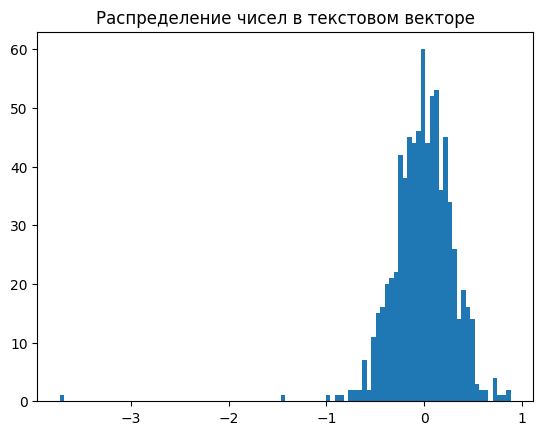

In [63]:
plt.hist(df.iloc[0]['text2vec'], bins=100)

plt.title('Распределение чисел в текстовом векторе')
plt.show()

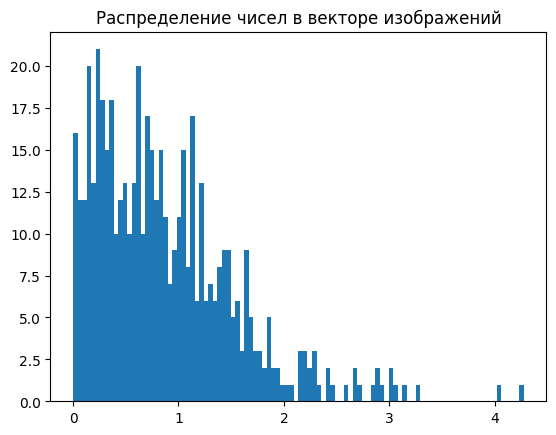

In [64]:
plt.hist(df.iloc[0]['image2vec'], bins=100)

plt.title('Распределение чисел в векторе изображений')
plt.show()

Вывод: необходимо маштабирование, т.к. текст и изображения имеют разное распределение.

In [65]:
# Масштабирование
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_valid = scaler.transform(X_valid)

#### LinearRegression

Обучим модель LinearRegression на созданных данных. 

В качестве целевой метрики будем использовать RMSE. Поскольку наша задача является задачей соотвествия (image-text matching), и нам, надо предсказать вероятность того, что вектор и изоображение соотвествуют друг другу. В контексте данной задачи, у целевой переменной нет статистических выбросов, а наша задача найти минимальную ошибку.

Для анализа будем использовать RMSE.
- подходит для задач регрессии.
- Измеряется в единицах целевого признака(легче интерпретируется)
- Чем ближе значение к нулю, тем лучше качество. 

In [66]:
model_lr = LinearRegression()
model_lr.fit(X_train, y_train)

LinearRegression()

In [67]:
lr_pred = model_lr.predict(X_valid)
rmse_lr = mean_squared_error(y_valid, lr_pred)** 0.5
print(f'RMSE для линейной регрессии: {round(rmse_lr, 2)}')

RMSE для линейной регрессии: 0.85


#### Полносвязанная нейронная сеть

In [68]:
# создание датасета
class CustomDataset(Dataset):
    def __init__(self, features, target):
        self.features = features
        self.target = target

    def __len__(self):
        return len(self.features)

    def __getitem__(self, idx):
        return self.features[idx], self.target[idx]

In [69]:
# создадим DataLoader
train_dataset = CustomDataset(X_train, y_train)
train_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=True)

test_dataset = CustomDataset(X_valid, y_valid)
test_dataloader = DataLoader(test_dataset, batch_size=32, shuffle=True)

In [70]:
# проверим работу
train_features, train_labels = next(iter(train_dataloader))

print(f"Feature batch shape: {train_features.size()}")
print(f"Labels batch shape: {train_labels.size()}")

Feature batch shape: torch.Size([32, 1280])
Labels batch shape: torch.Size([32, 1])


In [71]:
#Создадим собственную сеть с 6 слоями
class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.fc1 = nn.Linear(1280, 10240)
        self.dp1 = nn.Dropout(p=0.5)
        self.fc2 = nn.Linear(10240, 4096)
        self.dp2 = nn.Dropout(p=0.5)
        self.fc3 = nn.Linear(4096, 2048)
        self.dp3 = nn.Dropout(p=0.5)
        self.fc4 = nn.Linear(2048, 512)
        self.dp4 = nn.Dropout(p=0.5)
        self.fc5 = nn.Linear(512, 64)
        self.dp5 = nn.Dropout(p=0.5)
        self.fc6 = nn.Linear(64, 1)
        self.dp6 = nn.Dropout(p=0.5)

        self.dp = nn.Dropout(p=0.5)
        self.relu = nn.LeakyReLU()

    def forward(self, x):
        x = self.fc1(x)
        #x = self.relu(x)
        #x = self.dp(x)

        x = self.fc2(x)
        x = self.relu(x)
        #x = self.dp(x)

        x = self.fc3(x)
        x = self.relu(x)
        #x = self.dp(x)

        x = self.fc4(x)
        x = self.relu(x)
        #x = self.dp(x)

        x = self.fc5(x)
        x = self.relu(x)
        #x = self.dp(x)

        x = self.fc6(x)

        return x

In [72]:
models = Net()
models.to(device)

metric = torch.nn.MSELoss()
optimizer = torch.optim.Adam(models.parameters(), lr=5e-6)

epochs = 10
min_valid_loss = np.inf

In [73]:
#Запустим обучение. Промежуточный результат будем сохранять есть метрика качества на последней эпохе лучше предыдущей.
for e in range(epochs):
    train_loss = 0.0
    models.train()     # Optional when not using Model Specific layer
    for data, labels in train_dataloader:
        data, labels = data.to(device), labels.to(device)

        optimizer.zero_grad()
        target = models(data.to(torch.float32))
        #model(X_train.to(torch.float32))
        loss = torch.sqrt(metric(target,labels))
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * data.size(0)

    valid_loss = 0.0
    models.eval()     # Optional when not using Model Specific layer

    for data, labels in test_dataloader:
        data, labels = data.to(device), labels.to(device)

        target = models(data.to(torch.float32))
        loss = torch.sqrt(metric(target, labels))
        valid_loss += loss.item() * data.size(0)
        

    print(f'Epoch {e+1} \t\t Training Loss: {train_loss / len(train_dataloader)} \t\t Validation Loss: {valid_loss / len(test_dataloader)}')
    if min_valid_loss > valid_loss:
        print(f'Validation Loss Decreased({min_valid_loss:.6f}--->{valid_loss:.6f}) \t Saving The Model')
        min_valid_loss = valid_loss
        # Saving State Dict
        torch.save(models.state_dict(), TMP + '/saved_model.pth')

Epoch 1 		 Training Loss: 9.003137449479915 		 Validation Loss: 8.098479288510788
Validation Loss Decreased(inf--->315.840692) 	 Saving The Model
Epoch 2 		 Training Loss: 7.763475091958588 		 Validation Loss: 7.737279976789768
Validation Loss Decreased(315.840692--->301.753919) 	 Saving The Model
Epoch 3 		 Training Loss: 7.078230849721215 		 Validation Loss: 7.5175019311599245
Validation Loss Decreased(301.753919--->293.182575) 	 Saving The Model
Epoch 4 		 Training Loss: 6.372067298570817 		 Validation Loss: 7.412309978634883
Validation Loss Decreased(293.182575--->289.080089) 	 Saving The Model
Epoch 5 		 Training Loss: 5.67986898124218 		 Validation Loss: 7.329990810690782
Validation Loss Decreased(289.080089--->285.869642) 	 Saving The Model
Epoch 6 		 Training Loss: 4.984005749056285 		 Validation Loss: 7.289748268249707
Validation Loss Decreased(285.869642--->284.300182) 	 Saving The Model
Epoch 7 		 Training Loss: 4.271930287422782 		 Validation Loss: 7.323183732155042
Epoch 8

#### Шаг_9
## Тестирование модели
Настало время протестировать модель. Для этого получите эмбеддинги для всех тестовых изображений из папки test_images, выберите случайные 10 запросов из файла test_queries.csv и для каждого запроса выведите наиболее релевантное изображение. Сравните визуально качество поиска.



In [74]:
# загрузим модель
models = Net()
models.to(device)

models.load_state_dict(torch.load(TMP + '/saved_model.pth'))
models.eval()

Net(
  (fc1): Linear(in_features=1280, out_features=10240, bias=True)
  (dp1): Dropout(p=0.5, inplace=False)
  (fc2): Linear(in_features=10240, out_features=4096, bias=True)
  (dp2): Dropout(p=0.5, inplace=False)
  (fc3): Linear(in_features=4096, out_features=2048, bias=True)
  (dp3): Dropout(p=0.5, inplace=False)
  (fc4): Linear(in_features=2048, out_features=512, bias=True)
  (dp4): Dropout(p=0.5, inplace=False)
  (fc5): Linear(in_features=512, out_features=64, bias=True)
  (dp5): Dropout(p=0.5, inplace=False)
  (fc6): Linear(in_features=64, out_features=1, bias=True)
  (dp6): Dropout(p=0.5, inplace=False)
  (dp): Dropout(p=0.5, inplace=False)
  (relu): LeakyReLU(negative_slope=0.01)
)

In [75]:
#test_data_path

In [76]:
#Читаем файл test_images
test_images = pd.read_csv(os.path.join(data_path, 'test_images.csv'), index_col=0)
#Читаем файл test_queries
test_queries = pd.read_csv(os.path.join(data_path, 'test_queries.csv'), sep='|',index_col=0)

In [77]:
# загружаю изображение, которое будет показываться при запрете
urllib.request.urlretrieve('https://avatars.mds.yandex.net/i?id=b6d682087eb2223c2508aa78975e19c98ac7b554-9182309-images-thumbs&n=13', './cache/No-image-available.jpg')

('./cache/No-image-available.jpg', <http.client.HTTPMessage at 0x2b1cc4b5790>)

In [78]:
test_images.info()

<class 'pandas.core.frame.DataFrame'>
Index: 100 entries, 3356748019_2251399314.jpg to 2346402952_e47d0065b6.jpg
Empty DataFrame

In [79]:
data_info(test_queries)

Количество строк -  500
Количество столбцов - 3

<class 'pandas.core.frame.DataFrame'>
Int64Index: 500 entries, 0 to 499
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   query_id    500 non-null    object
 1   query_text  500 non-null    object
 2   image       500 non-null    object
dtypes: object(3)
memory usage: 15.6+ KB



,query_id,query_text,image
0,1177994172_10d143cb8d.jpg#0,"Two blonde boys , one in a camouflage shirt and the other in blue , are having a water fight .",1177994172_10d143cb8d.jpg
1,1177994172_10d143cb8d.jpg#1,Two boys are squirting water guns at each other .,1177994172_10d143cb8d.jpg
2,1177994172_10d143cb8d.jpg#2,Two boys spraying each other with water,1177994172_10d143cb8d.jpg



Описание данных


,query_id,query_text,image
count,500,500,500
unique,500,500,100
top,3396275223_ee080df8b5.jpg#0,I child slides into a wading pool full of water while an adult tosses a bucket of water on them .,2517284816_9b8fd3c6b6.jpg
freq,1,1,5


,Количество пропусков,% пропусков
query_id,0,0.00
query_text,0,0.00
image,0,0.00



Количество явных дубликатов в данных: 0
Доля явных дубликатов: 0.0 %



#### Векторизация текстовых изображений

In [92]:
image_vectors = {}

# воспользуемся ранее созданным методом
images2vector(test_data_path)

  0%|          | 0/100 [00:00<?, ?it/s]

In [93]:
# получаем 10 случайных примеров из тестового dataset'а
queries = list(test_queries.sample(MAX_SAMPLE)['query_text'])

In [94]:

def ban(txt):
    txt = txt.lower()
    lemmatizer = WordNetLemmatizer()
    word_tokens = word_tokenize(txt)
    lemmatized_output = ' '.join([lemmatizer.lemmatize(w) for w in RESTRICT])

    for word in RESTRICT:
        word_len = len(word.split())

        if word_len > 1:
            if word in txt:
                return True
        elif word_len == 1:
            if word in txt.split():
                return True

    return False

In [95]:
#Функция поиска
def search(txt):
    if ban(txt):
        # Выводим сообщение связанное с юридическими ограничениями
        return './cache/No-image-available.jpg', f'{txt}\nThis image is unavailable in your country in compliance with local laws', None

    text_vector = text2vector(txt)

    # создадим данные для модели
    vector = []
    img_path = []

    for key in image_vectors.keys():
        img_path.append(key)

        img = image_vectors[key]
        vector.append(np.concatenate((text_vector, img)))

    with torch.no_grad():
        input_tensor = scaler.transform(torch.FloatTensor(vector)) # Преобразуйте входные данные в тензор PyTorch
        prediction = models(torch.FloatTensor(input_tensor)).detach() # Получите предсказания от нейросети

        # Получение наилучшего индекса и изображения на основе предсказаний
    best_index = prediction.numpy().argmax(axis=0)[0]
    best_image = f'{test_data_path}\{img_path[best_index]}'

    return best_image, txt, prediction[best_index].numpy()[0]

In [96]:
images = []
labels = []
scores = []

In [97]:
for i in range(len(queries)):

    path_to_image, title, score = search(queries[i])

    images.append(path_to_image)
    if score == None:
        scores.append(None)
    else:
        scores.append(round(score, 3))
    labels.append(title)

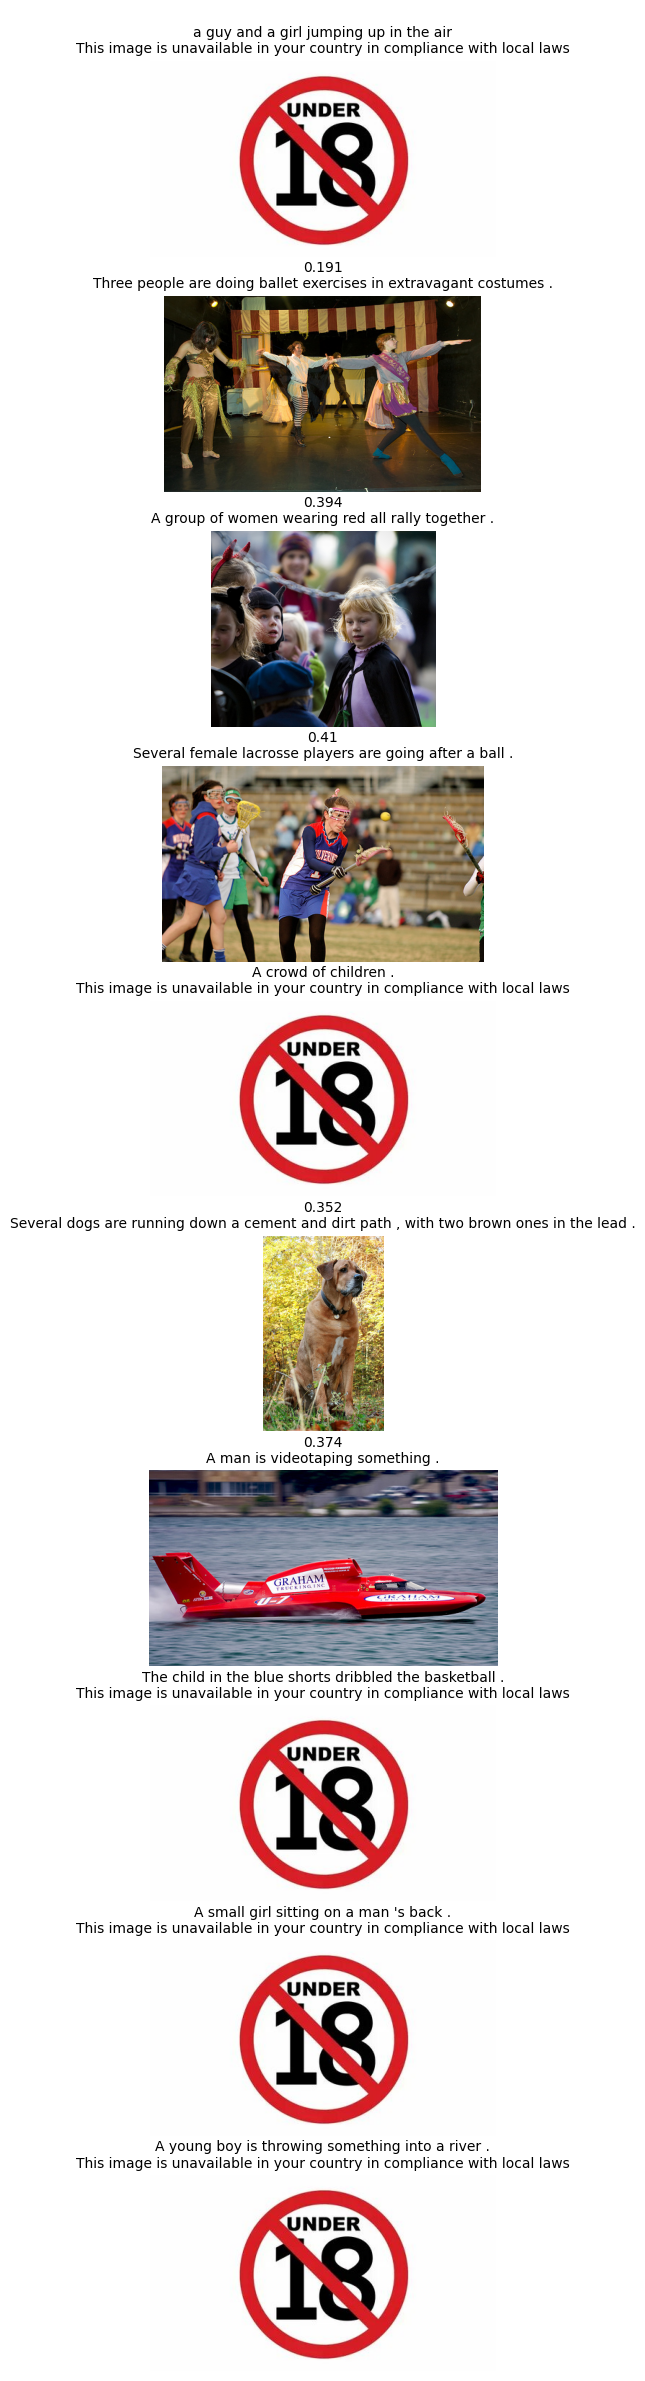

In [100]:
image_show(images, labels, scores)

#### Векторизация текста

In [143]:
# используем кэш
if os.path.exists(TMP + '/test_dataset.pickle'):
    test_queries = pickle.load(open(TMP + '/test_dataset.pickle', 'rb'))
else:
    with tqdm(total=test_queries.shape[0]) as pbar:
        test_queries['text2vec'] = test_queries['query_text'].apply(lambda x: text2vector(x))

    pickle.dump(train_df, file = open(TMP + '/test_dataset.pickle', 'wb'))

#### Объединение векторов

In [144]:
test_queries['image2vec'] = test_queries.apply(image2vector, axis=1)
test_queries['vector'] = test_queries.apply(join_vectors, axis=1)

In [145]:
test_queries.head(2)

,query_id,query_text,image,text2vec,image2vec,vector
0,1177994172_10d143cb8d.jpg#0,"Two blonde boys , one in a camouflage shirt and the other in blue , are having a water fight .",1177994172_10d143cb8d.jpg,"[0.03827642, -0.15529048, -0.25981954, 0.0059215934, 0.34787908, -0.22306791, 0.118427485, 0.52950025, 0.012771021, -0.15971045, -0.10463561, -0.19517231, -0.34066224, 0.26981357, -0.04919699, 0.631523, 0.2144406, 0.24942155, 0.014092134, 0.5358738, -0.017602682, -0.08061296, -0.22029749, 0.32840985, 0.5594937, -0.1269635, 0.056903694, 0.31023207, 0.05360492, 0.13999064, 0.3410923, -0.14227556, 0.11144574, -0.055010702, 0.16159835, 0.15550582, 0.10103975, -0.09514708, 0.108001664, 0.19379918, -0.624441, -0.3532959, -0.20618914, -0.14688805, -0.08113428, -0.6277874, 0.656421, -0.13743846, -0.1029786, -0.06105664, -0.4865126, 0.2864858, -0.07984155, -0.20177692, 0.05971973, 0.53443986, -0.13073191, -0.15196455, -0.24475665, -0.25280336, 0.29929695, 0.033495437, 0.130081, -0.58450466, -0.056356203, 0.2602267, -0.45699278, 0.40339097, -0.65710807, -0.06470916, -0.18801086, 0.099522635, -0.02007532, -0.334144, -0.15366593, 0.14779806, 0.024594748, 0.16710441, -0.22279786, -0.12204604, -0.17819591, 0.390061, -0.087304674, 0.63379526, 0.15124947, -0.05290004, -0.08230313, -0.044100527, -0.21212325, 0.7022589, -0.27624795, -0.054278135, 0.25734812, 0.2696421, 0.17452595, -0.06435793, 0.32507393, 0.2994883, 0.37769756, -0.04391052, ...]","[0.41534695, 2.3197756, 0.007788483, 2.3724763, 0.023016296, 0.3289689, 1.6659985, 1.8905618, 0.2285642, 0.039792597, 0.18829493, 1.3037397, 0.23662733, 0.04121075, 0.15816605, 0.9594745, 1.3749487, 0.02789235, 0.48108456, 1.0617709, 0.34697524, 0.10873738, 1.579511, 2.0900404, 2.2056375, 0.04548807, 0.03497155, 1.0392334, 0.03422375, 0.4420757, 0.8747445, 0.36676583, 0.020093534, 0.12403099, 0.8185484, 0.7289462, 0.23913021, 0.7194041, 1.3180157, 0.1465013, 0.19460413, 0.3098521, 0.7275442, 0.04080774, 2.3016202, 0.46214163, 0.39058787, 0.7530214, 0.5019121, 0.40482086, 0.20186234, 0.44019327, 1.4158443, 0.6699816, 0.08917728, 3.0013587, 0.036000494, 1.0470256, 0.57434815, 0.19821364, 0.114890866, 0.053331025, 2.1889436, 1.6953456, 0.014529932, 0.350013, 2.9318464, 0.27019674, 0.6938576, 0.6318065, 1.8908365, 0.5126183, 0.9178716, 0.07313158, 1.3077, 0.10149721, 0.97900695, 1.633701, 0.5997336, 2.3434286, 0.22634165, 0.5644698, 0.45562553, 2.9595542, 0.79642254, 0.2954471, 0.8027936, 0.36319533, 4.3462887, 1.1135242, 0.36109215, 2.9745603, 0.1002323, 2.7202334, 0.17695384, 1.1181276, 0.5828433, 0.73250043, 0.65135455, 2.7252603, ...]","[0.03827642, -0.15529048, -0.25981954, 0.0059215934, 0.34787908, -0.22306791, 0.118427485, 0.52950025, 0.012771021, -0.15971045, -0.10463561, -0.19517231, -0.34066224, 0.26981357, -0.04919699, 0.631523, 0.2144406, 0.24942155, 0.014092134, 0.5358738, -0.017602682, -0.08061296, -0.22029749, 0.32840985, 0.5594937, -0.1269635, 0.056903694, 0.31023207, 0.05360492, 0.13999064, 0.3410923, -0.14227556, 0.11144574, -0.055010702, 0.16159835, 0.15550582, 0.10103975, -0.09514708, 0.108001664, 0.19379918, -0.624441, -0.3532959, -0.20618914, -0.14688805, -0.08113428, -0.6277874, 0.656421, -0.13743846, -0.1029786, -0.06105664, -0.4865126, 0.2864858, -0.07984155, -0.20177692, 0.05971973, 0.53443986, -0.13073191, -0.15196455, -0.24475665, -0.25280336, 0.29929695, 0.033495437, 0.130081, -0.58450466, -0.056356203, 0.2602267, -0.45699278, 0.40339097, -0.65710807, -0.06470916, -0.18801086, 0.099522635, -0.02007532, -0.334144, -0.15366593, 0.14779806, 0.024594748, 0.16710441, -0.22279786, -0.12204604, -0.17819591, 0.390061, -0.087304674, 0.63379526, 0.15124947, -0.05290004, -0.08230313, -0.044100527, -0.21212325, 0.7022589, -0.27624795, -0.054278135, 0.25734812, 0.2696421, 0.17452595, -0.06435793, 0.32507393, 0.2994883, 0.37769756, -0.04391052, ...]"
1,1177994172_10d143cb8d.jpg#1,Two boys are squirting water guns at each other .,1177994172_10d143cb8d.jpg,"[0.10315005, 0.25970224, -0.0818

In [146]:
test_queries=test_queries.reset_index(drop=True)

In [147]:
df1 = test_queries.reset_index(drop=True).copy()

In [148]:
df1=df1.drop(columns=['query_text'])

In [149]:
df1 = scaler.transform(torch.FloatTensor(list(df1.loc[:, 'vector'].values)))

In [150]:
print(df1)

[[-0.16076166 -0.70594862 -0.84918073 ...  1.79186231 -0.51537208
   0.0514357 ]
 [ 0.24589098  1.9316407   0.29786411 ...  1.79186231 -0.51537208
   0.0514357 ]
 [ 0.79838633  1.66671449 -0.27013055 ...  1.79186231 -0.51537208
   0.0514357 ]
 ...
 [-0.49556236  1.52289059 -0.81238959 ... -1.30402035  0.85493345
  -0.73786898]
 [ 0.24821628  1.57517331 -1.57415517 ... -1.30402035  0.85493345
  -0.73786898]
 [-1.03858357  1.35652249  0.29740509 ... -1.30402035  0.85493345
  -0.73786898]]


In [151]:
prediction_lr=model_lr.predict(df1)
prediction_net=models(torch.FloatTensor(df1)).detach().numpy()

In [152]:
test_queries['probability_lr'] = prediction_lr
test_queries['probability_net'] = prediction_net

In [153]:
test_queries=test_queries.drop(columns=['text2vec','image2vec','vector'])

In [154]:
test_queries.sample(15)

,query_id,query_text,image,probability_lr,probability_net
206,3036971334_78187a9570.jpg#1,A man is jumping off a rock into a pool of water while three others watch .,3036971334_78187a9570.jpg,1.07,0.31
218,3044745642_1d0784ff29.jpg#3,Two people are in a tent near a brick wall .,3044745642_1d0784ff29.jpg,1.49,0.25
39,1745110280_0cbff5e273.jpg#4,The brown dog is wearing a black collar .,1745110280_0cbff5e273.jpg,0.63,0.50
477,862177617_c2c0581075.jpg#2,"A person with blue hair , a baseball cap , and a hood on stands outdoors in a crowd .",862177617_c2c0581075.jpg,-0.08,0.12
433,404850242_3a55a4c874.jpg#3,A woman in a red coat takes a picture near marble columns at twilight .,404850242_3a55a4c874.jpg,0.84,0.25
68,2121140070_a09644550b.jpg#3,kids play ultimate Frisbee .,2121140070_a09644550b.jpg,-1.00,0.03
397,3555573680_41c1540a86.jpg#2,A man on a waterski is performing a jump in the air .,3555573680_41c1540a86.jpg,-0.11,0.29
337,3438981089_2ef1a6353c.jpg#2,A man on an orange bike .,3438981089_2ef1a6353c.jpg,0.06,0.22
43,186346360_541047336f.jpg#3,A woman poses for a picture while in front of a lake .,186346360_541047336f.jpg,1.54,0.27
126,2505465055_f1e6cf9b76.jpg#1,A tan dog runs through the brush .,2505465055_f1e6cf9b76.jpg,1.83,0.43


In [155]:
# загружаю изображение, которое будет показываться при запрете
urllib.request.urlretrieve('https://avatars.mds.yandex.net/i?id=b6d682087eb2223c2508aa78975e19c98ac7b554-9182309-images-thumbs&n=13', './cache/No-image-available.jpg')

('./cache/No-image-available.jpg', <http.client.HTTPMessage at 0x28eb5b1cf40>)

In [157]:
visual_set = test_queries[test_queries['probability_net'] > 0.5].sample(MAX_SAMPLE).copy()
visual_set.reset_index(inplace=True)

images = []
labels = []
probability_lr = []
probability_net = []


In [158]:
for i in range(visual_set.shape[0]):
    if any(word in visual_set['query_text'][i].lower() for word in RESTRICT):  
        images.append('./cache/No-image-available.jpg')
        labels.append(visual_set.iloc[i]['query_text'])
        probability_lr.append(visual_set.iloc[i]['probability_lr'])
        probability_net.append(visual_set.iloc[i]['probability_net'])
    else:
        images.append(f'{test_data_path}/{visual_set.iloc[i]["image"]}')
        labels.append(visual_set.iloc[i]['query_text'])
        probability_lr.append(visual_set.iloc[i]['probability_lr'])
        probability_net.append(visual_set.iloc[i]['probability_net'])

#image_show(images, labels, probability_net)

In [159]:
images

['C:\\Users\\ВТБ\\Desktop\\practicum\\Сборный 4\\to_upload\\\\test_images/3517023411_a8fbd15230.jpg',
 'C:\\Users\\ВТБ\\Desktop\\practicum\\Сборный 4\\to_upload\\\\test_images/3488087117_2719647989.jpg',
 'C:\\Users\\ВТБ\\Desktop\\practicum\\Сборный 4\\to_upload\\\\test_images/957682378_46c3b07bcd.jpg',
 'C:\\Users\\ВТБ\\Desktop\\practicum\\Сборный 4\\to_upload\\\\test_images/3287969199_08e775d896.jpg',
 'C:\\Users\\ВТБ\\Desktop\\practicum\\Сборный 4\\to_upload\\\\test_images/3044359043_627488ddf0.jpg',
 'C:\\Users\\ВТБ\\Desktop\\practicum\\Сборный 4\\to_upload\\\\test_images/3033612929_764d977bd5.jpg',
 './cache/No-image-available.jpg',
 'C:\\Users\\ВТБ\\Desktop\\practicum\\Сборный 4\\to_upload\\\\test_images/123997871_6a9ca987b1.jpg',
 'C:\\Users\\ВТБ\\Desktop\\practicum\\Сборный 4\\to_upload\\\\test_images/1429546659_44cb09cbe2.jpg',
 'C:\\Users\\ВТБ\\Desktop\\practicum\\Сборный 4\\to_upload\\\\test_images/3488087117_2719647989.jpg']